# Zrozumienie danych – 10 kroków (EDA)

Notatnik realizuje listę **„10 kroków do lepszego zrozumienia danych”** na zbiorze `verses.csv` (zwrotki utworów).

- Obserwacja: **jedna zwrotka** (`verse`)
- Cel: szybkie zrozumienie rozmiaru, struktury, jakości i rozkładów przed dalszą analizą tekstu.


In [37]:
import pandas as pd
import numpy as np
from pathlib import Path

# Wczytanie danych (spróbuj kilku typowych ścieżek)
CANDIDATES = [
    Path("verses.csv"),
    Path("data/verses.csv"),
    Path("../data/verses.csv"),
]

for p in CANDIDATES:
    if p.exists():
        csv_path = p
        break
else:
    raise FileNotFoundError(f"Nie znaleziono verses.csv. Sprawdzone: {[str(x) for x in CANDIDATES]}")

df = pd.read_csv(csv_path)

df.shape


(858, 8)

### Krok 1. Poznaj rozmiar analizowanego zbioru
Wynik `df.shape` to *(liczba obserwacji, liczba zmiennych)*.


In [ ]:
# Wczytaj dane (używamy oczyszczonego `data/verses_cleaned_final.csv` — 1 wiersz = 1 artysta)
import pandas as pd
csv_path = 'data/verses_cleaned_final.csv'
print('Wczytuję plik (wersja oczyszczona):', csv_path)
df = pd.read_csv(csv_path)
print('Wiersze, kolumny:', df.shape)
# Uwaga: kolumny 'song_title' i 'source_path' zostały wcześniej usunięte; tu dodatkowo zastosowano filtrowanie i usuwanie meta-blocków.

Wczytuję plik: data/verses_clean.csv
Wiersze, kolumny: (858, 6)


### Krok 2. Rzuć okiem na dane
Wyświetlamy próbkę surowych danych, aby szybko ocenić strukturę i sens kolumn.


In [39]:
df.dtypes


song_id        int64
author           str
verse_order    int64
text             str
num_lines      int64
char_count     int64
dtype: object

### Krok 3. Zweryfikuj typy poszczególnych zmiennych
Sprawdzamy typy danych – pomaga to dobrać dalsze metody (statystyki, wykresy, czyszczenie).


In [40]:
# Podstawowe informacje o DataFrame
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   song_id      858 non-null    int64
 1   author       858 non-null    str  
 2   verse_order  858 non-null    int64
 3   text         858 non-null    str  
 4   num_lines    858 non-null    int64
 5   char_count   858 non-null    int64
dtypes: int64(4), str(2)
memory usage: 40.3 KB


In [41]:
# Krok 4: Podsumowanie numerycznych zmiennych
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()


,song_id,verse_order,num_lines,char_count
count,858.000000,858.0,858.000000,858.000000
mean,429.500000,1.0,38.115385,1143.227273
std,247.827561,0.0,210.606469,1557.549415
min,1.000000,1.0,2.000000,18.000000
25%,215.250000,1.0,17.000000,750.250000
50%,429.500000,1.0,23.000000,943.000000
75%,643.750000,1.0,31.000000,1245.000000
max,858.000000,1.0,3585.000000,25989.000000


### Krok 4. Zbuduj podstawowe podsumowanie zbioru
Podsumowanie robimy głównie dla zmiennych numerycznych (np. `num_lines`, `char_count`).


In [42]:
# Krok 5: Braki danych
nulls = pd.DataFrame({
    "is_null": df.isnull().any(),
    "num_nulls": df.isnull().sum(),
    "pct_nulls": (df.isnull().mean()*100).round(2)
}).sort_values("pct_nulls", ascending=False)

nulls


,is_null,num_nulls,pct_nulls
song_id,False,0,0.0
author,False,0,0.0
verse_order,False,0,0.0
text,False,0,0.0
num_lines,False,0,0.0
char_count,False,0,0.0


### Krok 5. Sprawdź czy w zbiorze występują braki danych
Weryfikujemy braki (NULL/NaN) w każdej kolumnie.


In [43]:
# Krok 6: Skośność rozkładów (tylko numeryczne)
# UWAGA: df.skew() działa dla zmiennych numerycznych; dla tekstu to bez sensu.
skewness = df[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)
skewness


num_lines      16.759747
char_count     14.265603
verse_order     0.000000
song_id         0.000000
dtype: float64

### Krok 6. Zbadaj skośność rozkładów
Skośność pomaga ocenić, czy rozkład jest symetryczny czy mocno „ciągnie” w jedną stronę.


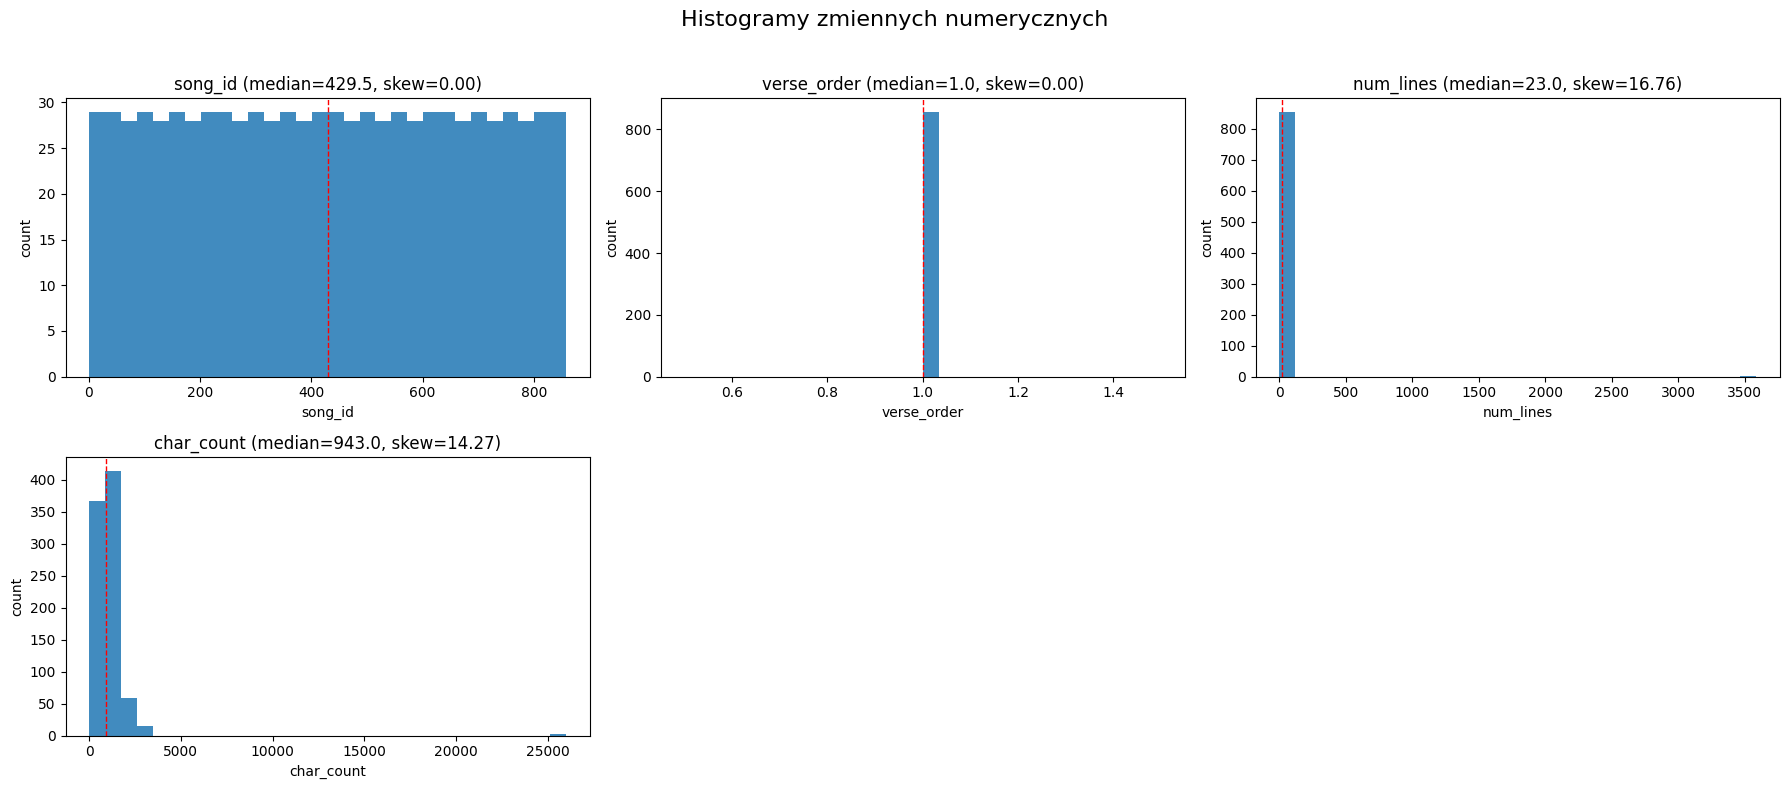

In [44]:
# Krok 7: Histogramy zmiennych numerycznych — czytelniejsza wersja
import math
import numpy as np

try:
    import seaborn as sns
    sns.set_style('whitegrid')
    use_sns = True
except Exception:
    use_sns = False

cols = numeric_cols.tolist()
n = len(cols)
if n == 0:
    print('Brak zmiennych numerycznych do wyświetlenia')
else:
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df[col].dropna()
        if use_sns:
            sns.histplot(data, bins=30, kde=False, ax=ax, color='C0')
        else:
            ax.hist(data, bins=30, color='C0', alpha=0.85)
        med = data.median()
        sk = data.skew()
        ax.axvline(med, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{col} (median={med:.1f}, skew={sk:.2f})")
        ax.set_xlabel(col)
        ax.set_ylabel('count')

    # usuń puste osie
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('Histogramy zmiennych numerycznych', fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Krok 7. Sprawdź rozkład zmiennych numerycznych
Dodajemy warstwę wizualną: histogramy.


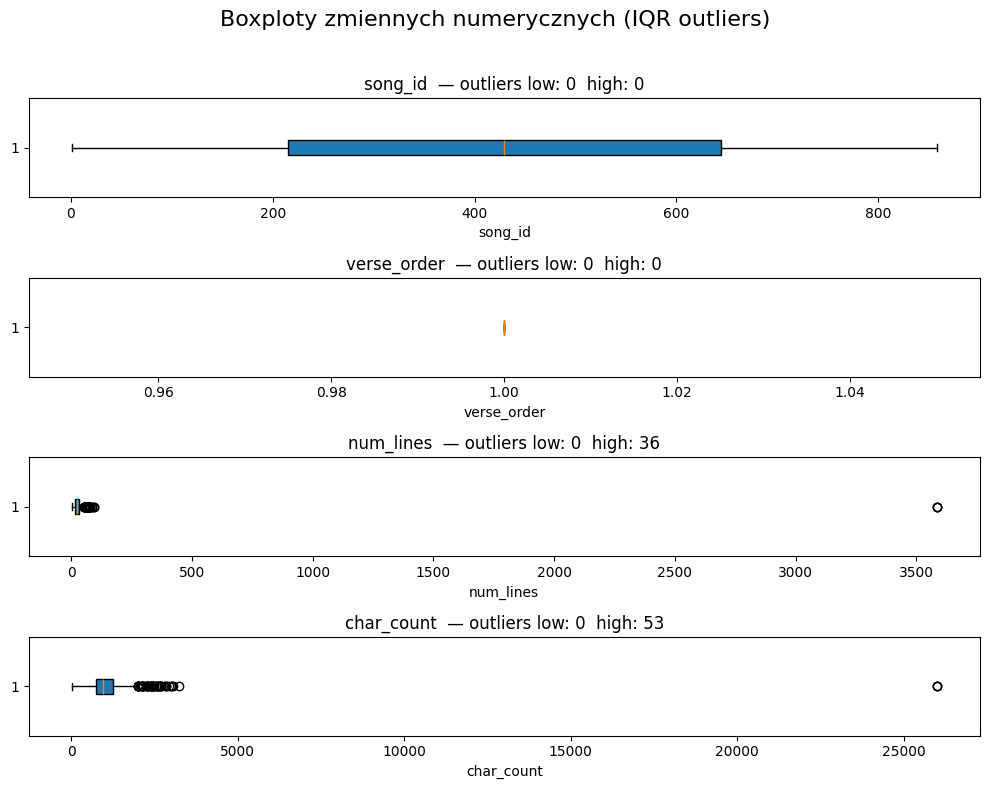

In [45]:
# Krok 8: Boxploty + podsumowanie outlierów (ulepszone wizualnie)
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    use_sns = True
except Exception:
    use_sns = False

cols = numeric_cols.tolist()
if len(cols) == 0:
    print('Brak zmiennych numerycznych do wyświetlenia')
else:
    # policz granice IQR
    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    iqr = q3 - q1
    low_boundary = q1 - 1.5 * iqr
    upp_boundary = q3 + 1.5 * iqr

    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cols):
        ax = axes[i]
        data = df[col].dropna()
        if use_sns:
            sns.boxplot(x=data, orient='h', ax=ax, color='C0')
        else:
            ax.boxplot(data, vert=False, patch_artist=True)
        low = int((data < low_boundary[col]).sum())
        high = int((data > upp_boundary[col]).sum())
        ax.set_title(f"{col}  — outliers low: {low}  high: {high}")
        ax.set_xlabel(col)

    fig.suptitle('Boxploty zmiennych numerycznych (IQR outliers)', fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Podsumowanie outlierów jako tabela
    outliers_summary = pd.DataFrame({
        'low_boundary': low_boundary,
        'upp_boundary': upp_boundary,
        'num_outliers_low': (df[cols] < low_boundary).sum(),
        'num_outliers_high': (df[cols] > upp_boundary).sum(),
    })
    outliers_summary

### Krok 8. Zidentyfikuj obserwacje odstające
Najpierw wizualnie (boxplot), potem liczbowo regułą IQR.


In [46]:
# Krok 9: Zmienne kategoryczne – liczności kategorii
cat_cols = df.select_dtypes(include=["object"]).columns

# Dla czytelności: pokazujemy top 20 kategorii dla wybranych kolumn
for col in cat_cols:
    print("\n==============================")
    print(f"{col} (unikalne: {df[col].nunique(dropna=True)})")
    print(df[col].value_counts(dropna=False).head(20))



author (unikalne: 858)
author
$ierra         1
2020           1
2K             1
2sty           1
360MI          1
3Y Gun Kara    1
4tune          1
730 Huncho     1
ADM            1
AK-47          1
AKS            1
ALBI           1
ARTVR          1
ATR MF         1
AdMa           1
Adam Bodnar    1
Adam           1
Adamz          1
Adi Nowak      1
Aero           1
Name: count, dtype: int64

text (unikalne: 642)
text
#Hot16Challenge2\nCzekamy                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

/tmp/ipykernel_193169/1791120555.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


### Krok 9. Sprawdź liczności zmiennych kategorycznych
Sprawdzamy, ile jest kategorii i które dominują (np. autorzy, tytuły).


In [47]:
# Krok 10: Zależności pomiędzy zmiennymi
# A) Korelacja pomiędzy zmiennymi numerycznymi
corr = df[numeric_cols].corr(method="spearman")  # bezpieczniej niż pearson przy outlierach
corr


,song_id,verse_order,num_lines,char_count
song_id,1.000000,NaN,0.020664,-0.035451
verse_order,NaN,NaN,NaN,NaN
num_lines,0.020664,NaN,1.000000,0.798102
char_count,-0.035451,NaN,0.798102,1.000000


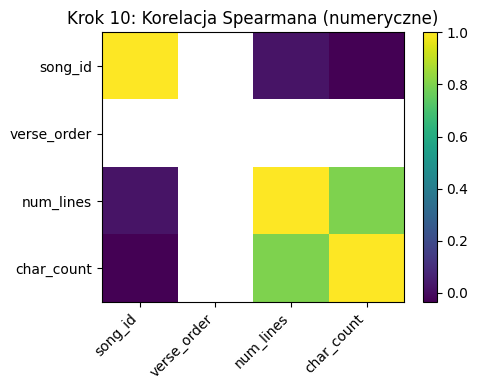

In [48]:
# Wizualizacja korelacji (heatmapa w matplotlib)
plt.figure(figsize=(5,4))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Krok 10: Korelacja Spearmana (numeryczne)")
plt.colorbar()
plt.tight_layout()
plt.show()


### Krok 10. Zbadaj zależności pomiędzy zmiennymi
Dla danych tekstowych sensownie zaczynamy od korelacji zmiennych numerycznych (np. `num_lines` vs `char_count`).
